# CASTalign Testground

Two-hop alignment pipeline: BARseq ex-vivo slices â†’ ex-vivo block â†’ in-vivo stack.

## Pipeline Structure
```
```

## Workflow
1. **Load graph** with in-vivo reference, ex-vivo block, and subslices
2. **Select slice** via dropdown widget
3. **Align slices â†’ block** using one of three modes:
   - Mode A: Padded, block as base (point-based, RAM-heavy)
   - Mode B: No padding, block as base (parametric only, low RAM)
   - Mode C: No padding, slice as base / block movable (point-based, low RAM)
4. **Align block â†’ in-vivo** (Mode D, done once â€” 3D vs 3D)
5. **Verify** alignment with Pearson correlation + napari overlay
6. **Refine** with Triangulation2D for edge warping
7. **Export** warped images as TIFF
8. **Visualize** all aligned slices with GraphViewer

---

## 1. Imports & Setup

In [28]:
# =============================================================================
# IMPORTS & SETUP
# =============================================================================
%reset -f

import sys
import gc
from pathlib import Path
import numpy as np
import tifffile
import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy.stats import pearsonr

# =============================================================================
# PATH SETUP
# =============================================================================
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent  # cell2cell-alignment/

# Add project root to path for local_config and utilities
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# =============================================================================
# LOCAL CONFIG (user-specific paths)
# =============================================================================
try:
    from local_config import GRAPH_PATH
except ImportError:
    raise ImportError(
        "local_config.py not found.\n"
        "Copy local_config.example.py to local_config.py and fill in your paths:\n"
        "    cp local_config.example.py local_config.py"
    )

# =============================================================================
# CASTALIGN IMPORTS
# =============================================================================
try:
    import castalign as ca
    import castalign.gui as ca_gui
    from castalign.gui import GraphViewer
    from castalign import ndarray_shifted
    import castalign.utils as ca_utils
    print("Imported castalign")
except ImportError:
    # Fallback to linestuffup if castalign not available
    import linestuffup as ca
    import linestuffup.gui as ca_gui
    from linestuffup import ndarray_shifted
    import linestuffup.utils as ca_utils
    try:
        from linestuffup.gui import GraphViewer
    except ImportError:
        GraphViewer = None
        print("Warning: GraphViewer not available in this version")
    print("Imported linestuffup (castalign fallback)")

# =============================================================================
# PROJECT UTILITIES
# =============================================================================
from utilities.graph_viz_fix import patch_castalign_visualise
patch_castalign_visualise()

# =============================================================================
# JUPYTER MAGIC
# =============================================================================
%load_ext autoreload
%autoreload 2

# Disable label auto-detection
ca_utils.image_is_label = lambda img: False

print()
print("="*60)
print("CASTALIGN TESTGROUND")
print("="*60)
print("Imports complete")
print("GraphViz patched (SVG output)")
print("Auto-reload enabled")
print("="*60)

Imported castalign
✓ Patched Graph.visualise() to use SVG format (vector, preserves text layout)
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

CASTALIGN TESTGROUND
Imports complete
GraphViz patched (SVG output)
Auto-reload enabled


## 2. Path Configuration

In [29]:
# =============================================================================
# PATH CONFIGURATION (from local_config.py)
# =============================================================================
#
# All paths are set in local_config.py (project root, gitignored).
# Edit that file to change data locations. It contains:
#   BLOCK_STACK_PATH_RED   — ex-vivo block TIFF, red (alignment) channel
#   BLOCK_STACK_PATH_GREEN — ex-vivo block TIFF, green channel (optional)
#   INVIVO_PATH_RED        — in-vivo 2P TIFF, red (alignment) channel
#   INVIVO_PATH_GREEN      — in-vivo 2P TIFF, green channel (optional)
#   SUBSLICE_DIR           — BARseq subslice overlays (optional)
#   GRAPH_PATH             — alignment graph .db file (blank = auto-derive)
#   (DATA_ROOT / OUTPUT_ROOT used only by preprocessing scripts.)
#
# Template: local_config.example.py
#
# WARNING: SQLite over Samba (Mac accessing server files)
# --------------------------------------------------------
# The graph .db files are SQLite databases. Writing SQLite over network mounts
# (Samba/SMB) can sometimes cause issues:
#   - "database is locked" errors
#   - Corruption errors on save
#   - Hanging during graph.save()
#
# If you encounter these issues, consider:
#   1. Copy graph locally, align, copy back
#   2. Run alignment directly on the server (SSH + X11 forwarding)
# =============================================================================

# Resolve GRAPH_PATH. Mirrors subslice_graph_builder.build_subslice_graph
# (line ~705): blank GRAPH_PATH auto-derives <data_parent>/alignment/<subject>_graph.db.
# Without this branch, Path("") collapses to Path(".") and the load below
# fails several cells downstream with a confusing sqlite/dir error.
if GRAPH_PATH:
    GRAPH_PATH = Path(GRAPH_PATH)
else:
    from alignment.subslice_graph_builder import _derive_graph_path
    from local_config import BLOCK_STACK_PATH_RED, INVIVO_PATH_RED
    GRAPH_PATH = _derive_graph_path(
        Path(BLOCK_STACK_PATH_RED) if BLOCK_STACK_PATH_RED else None,
        Path(INVIVO_PATH_RED) if INVIVO_PATH_RED else None,
    )

WARPED_OUTPUT_DIR = GRAPH_PATH.parent / "warped_output"

print("Path verification:")
print(f"  Graph file:    {'OK' if GRAPH_PATH.exists() else 'NOT FOUND'} {GRAPH_PATH}")
print(f"  Warped output: {'OK' if WARPED_OUTPUT_DIR.exists() else 'WILL BE CREATED'} {WARPED_OUTPUT_DIR}")


Path verification:
  Graph file:    OK C:\Users\David\lab_local\projects\cell_type\data\050526 BY95\alignment\BY95_graph.db
  Warped output: WILL BE CREATED C:\Users\David\lab_local\projects\cell_type\data\050526 BY95\alignment\warped_output


## 3. Load Graph

In [30]:
# Play this to load graph
# =============================================================================
# LOAD GRAPH
# =============================================================================
if not GRAPH_PATH.exists():
    raise FileNotFoundError(
        f"Graph not found: {GRAPH_PATH}\n"
        "Run subslice_graph_builder.py to build it first."
    )

g = ca.Graph.load(str(GRAPH_PATH))

# Node names - the alignment-canonical (red) channel of each 2P volume.
# Sibling green nodes (invivo_ref_green / ex_vivo_block_green) are joined to
# these via castalign.base.Identity edges and compose for free.
invivo_node = "invivo_ref_red"
block_node = "ex_vivo_block_red"

# Non-slice node names: both 2P-volume channels and the `ex_vivo_rigid` ref
# node (added post-promote in cell 9b). Subtracted from `slice_nodes` below.
NON_SLICE_NODES = {
    "invivo_ref_red", "invivo_ref_green",
    "ex_vivo_block_red", "ex_vivo_block_green",
    "invivo_ref_z_tilt_corrected_red", "invivo_ref_z_tilt_corrected_green",
    "ex_vivo_rigid",
}

# =============================================================================
# VERIFY EXPECTED NODES
# =============================================================================
all_nodes = list(g.nodes)

if block_node not in g.nodes:
    raise ValueError(f"'{block_node}' not in graph. Rebuild graph with block_path set.")

slice_nodes = sorted([n for n in all_nodes if n not in NON_SLICE_NODES])

aligned_slices = []
unaligned_slices = []
for s in slice_nodes:
    if s in g.edges and block_node in g.edges[s]:
        aligned_slices.append(s)
    else:
        unaligned_slices.append(s)

block_to_invivo_aligned = (
    block_node in g.edges and invivo_node in g.edges.get(block_node, {})
)

print("="*60)
print("GRAPH LOADED")
print("="*60)
print(f"Graph: {g.name}")
print(f"Path:  {GRAPH_PATH}")
print(f"Total nodes: {len(all_nodes)}")
print(f"Subslices: {len(slice_nodes)}")
print(f"  Aligned to block: {len(aligned_slices)}")
print(f"  Unaligned: {len(unaligned_slices)}")
print(f"Block -> InVivo: {'ALIGNED' if block_to_invivo_aligned else 'NOT ALIGNED (run Mode D)'}")
print("="*60)

GRAPH LOADED
Graph: castalign_test
Path:  C:\Users\David\lab_local\projects\cell_type\data\050526 BY95\alignment\BY95_graph.db
Total nodes: 6
Subslices: 0
  Aligned to block: 0
  Unaligned: 0
Block -> InVivo: ALIGNED


### (Optional) Rebuild graph from scratch

**Destructive** — wipes the `.db` file and every fitted edge. Use after editing `local_config.py` paths or when a schema migration (e.g. the 2026-04-28 multi-channel refactor) requires a fresh graph.

Flow: flip `REBUILD = True` in the cell below, run it, then re-run the load cell that follows to reload `g`.

In [ ]:
# (Optional) Rebuild the graph from scratch.
# DESTRUCTIVE - wipes the .db file and every fitted edge.
# Use after editing local_config.py paths or after a schema migration.
# Flow: flip REBUILD = True, run this cell, then re-run the load cell below to reload `g`.
REBUILD = False

if REBUILD:
    from alignment.subslice_graph_builder import build_subslice_graph
    build_subslice_graph(force_rebuild=True)
    print('Rebuild complete. Set REBUILD = False above, then re-run the load cell below to reload `g`.')
else:
    print('REBUILD is False - skipping. Flip to True only when you actually want to wipe.')

## (Optional) Manual node add

Add an ad-hoc 2P volume or single subslice to the graph on disk, between the build cell above and the load cell below. Useful for trying out new nodes (e.g. an intermediate ex-vivo run, an extra subslice) without extending `subslice_graph_builder.py`.

Set `MANUAL_ADD = True` to activate; default is a no-op. A `REBUILD = True` in the cell above wipes the `.db`, so manual additions need to be re-run after a rebuild — by design, to force re-declaration.

In [ ]:
# ============================================================
# MANUAL NODE ADD (optional)
# ------------------------------------------------------------
# Adds a 2P volume or a single subslice to the graph on disk.
# Runs between the build cell and the load cell, so rebuilds via
# REBUILD=True will WIPE manual additions — that's intentional:
# re-running this cell after a rebuild forces the manual
# additions to be re-declared.
#
# Set MANUAL_ADD = True to activate. Leave False for a no-op.
# ============================================================

MANUAL_ADD = False
KIND = "2p"   # "2p" or "subslice"

# --- 2p config (used when KIND == "2p") ---
BASE_NAME = "ex_vivo_run1"
RED_PATH = r"C:\Users\David\lab_local\projects\cell_type\data\050126 BY100\by100 exvivo red only 1st run.tif"        # blank = skip red
GREEN_PATH = ""      # blank = skip green (single-channel allowed)
SCOPE_FALLBACK = "huang_lab"   # used only if TIFF lacks XResolution metadata

# --- subslice config (used when KIND == "subslice") ---
SUBSLICE_PATH = ""
SUBSLICE_NODE_NAME = ""           # blank = use file stem
SUBSLICE_SPACING = (20.0, 1.0, 2.34)   # (Z, Y, X) µm/px

# ============================================================
# Execution
# ============================================================

if MANUAL_ADD:
    from alignment.subslice_graph_builder import (
        load_block_stack,
        load_single_subslice,
        resolve_spacing,
        _add_volume_channels,
        save_graph,
    )

    if not GRAPH_PATH.exists():
        raise FileNotFoundError(
            f"Graph .db not found at {GRAPH_PATH}. Run the rebuild cell above with "
            "REBUILD = True first to build the base graph."
        )

    g_manual = ca.Graph.load(str(GRAPH_PATH))
    n_before = len(g_manual.nodes)

    if KIND == "2p":
        if not RED_PATH and not GREEN_PATH:
            raise ValueError("Set at least one of RED_PATH / GREEN_PATH for KIND='2p'.")

        red_stack = green_stack = None
        red_spacing = green_spacing = None

        if RED_PATH:
            red_stack = load_block_stack(RED_PATH)
            red_spacing, _ = resolve_spacing(RED_PATH, SCOPE_FALLBACK, "SCOPE_FALLBACK (manual cell)")

        if GREEN_PATH:
            green_stack = load_block_stack(GREEN_PATH)
            green_spacing, _ = resolve_spacing(GREEN_PATH, SCOPE_FALLBACK, "SCOPE_FALLBACK (manual cell)")

        _add_volume_channels(
            g_manual, BASE_NAME,
            red_stack=red_stack, green_stack=green_stack,
            red_spacing=red_spacing, green_spacing=green_spacing,
        )

    elif KIND == "subslice":
        if not SUBSLICE_PATH:
            raise ValueError("Set SUBSLICE_PATH for KIND='subslice'.")
        node_name = SUBSLICE_NODE_NAME or Path(SUBSLICE_PATH).stem
        if node_name in g_manual.nodes:
            print(f"  {node_name} already in graph — skipping")
        else:
            img = load_single_subslice(SUBSLICE_PATH)
            g_manual.add_node(
                node_name, image=img, compression="normal",
                metadata={"spacing": SUBSLICE_SPACING, "anisotropic": True,
                          "source": "manual cell"},
            )
            print(f"  Added subslice node: {node_name}  shape {img.shape}  spacing {SUBSLICE_SPACING}")

    else:
        raise ValueError(f"KIND must be '2p' or 'subslice', got {KIND!r}")

    n_after = len(g_manual.nodes)
    if n_after > n_before:
        save_graph(g_manual, GRAPH_PATH)
        print(f"Manual add: {n_before} → {n_after} nodes; saved to {GRAPH_PATH}")
    else:
        print(f"Manual add: no new nodes added ({n_before} unchanged); not re-saving")

    del g_manual

## 4. Slice Selector

Use the dropdown to select which slice to align. Green = aligned, Red = unaligned.

In [ ]:
# =============================================================================
# SLICE SELECTOR WIDGET
# =============================================================================
import re

def extract_slice_number(node_name):
    """Extract slice number from node name like 'slice10_subslice_mScarlet_cellmask'."""
    match = re.match(r'slice(\d+)', node_name)
    return int(match.group(1)) if match else 0

# Sort slice nodes by number
slice_nodes = sorted(slice_nodes, key=extract_slice_number)

# Create options with alignment status
def get_slice_options():
    """Generate dropdown options with alignment status and transform type."""
    options = []
    for s in slice_nodes:
        is_aligned = s in aligned_slices
        num = extract_slice_number(s)
        if is_aligned:
            t = g.get_transform(s, block_node)
            tname = type(t).__name__
            options.append((f"OK [{tname}] Slice {num}", s))
        else:
            options.append((f"o  Slice {num}", s))
    return options

# Create widget
slice_dropdown = widgets.Dropdown(
    options=get_slice_options(),
    description="Select:",
    style={"description_width": "60px"},
    layout=widgets.Layout(width="350px")
)

# Info display
info_output = widgets.Output()

def show_slice_info(node):
    """Display info for a slice node."""
    with info_output:
        clear_output(wait=True)
        img = g.get_image(node)
        is_aligned = node in aligned_slices
        
        print(f"Selected: {node}")
        print(f"Shape: {img.shape}")
        print(f"Status: {'Aligned to block' if is_aligned else 'Not aligned'}")
        
        if is_aligned:
            t = g.get_transform(node, block_node)
            print(f"Transform: {type(t).__name__}")

def on_slice_change(change):
    """Update info when slice selection changes."""
    show_slice_info(change["new"])

# Attach observer FIRST
slice_dropdown.observe(on_slice_change, names="value")

# Display widget
print("Select a slice to align:")
print("  OK [TransformType] = aligned to block")
print("  o  = not yet aligned")
print()
display(widgets.HBox([slice_dropdown, info_output]))

# Show initial info (observer won't fire since value hasn't changed)
show_slice_info(slice_dropdown.value)

def get_selected_slice():
    """Get currently selected slice name."""
    return slice_dropdown.value

## 5. Alignment Utilities

Helper functions used by all alignment modes.

In [31]:
# =============================================================================
# ALIGNMENT UTILITIES
# =============================================================================

def get_initial_transform_slice_to_block():
    """
    Initial transform for slice -> ex-vivo block alignment.
    
    Both are ex-vivo tissue, so no large rotation is expected.
    The block is a 3D 2-photon volume of the tissue before slicing.
    
    TODO: May need adjustment (e.g., xrotate=90) depending on how
    the block was imaged relative to the slices. Test and adjust.
    """
    return ca.Identity()


def load_and_pad_slice(slice_name, pad_z=25):
    """
    Load a slice from the graph and pad it in z for point-based transforms.
    
    Parameters
    ----------
    slice_name : str
        Name of the slice node in the graph
    pad_z : int
        Number of blank slices above and below (total z = 2*pad_z + 1)
    
    Returns
    -------
    padded : np.ndarray
        Padded volume with original slice at z=pad_z
    """
    slice_img = g.get_image(slice_name)
    padding_value = slice_img.mean() * 0.90
    padded = np.full((2 * pad_z + 1, *slice_img.shape[1:]), padding_value, dtype=slice_img.dtype)
    padded[pad_z] = slice_img[0]
    return padded


def compute_alignment_quality(fixed_img, movable_img, transform):
    """
    Apply a transform and compute Pearson correlation as alignment quality metric.
    
    Parameters
    ----------
    fixed_img : np.ndarray
        The fixed/reference image
    movable_img : np.ndarray
        The movable image (pre-transform)
    transform : Transform
        The alignment transform (movable -> fixed direction)
    
    Returns
    -------
    r : float
        Pearson correlation coefficient between overlapping regions
    warped : np.ndarray
        The transformed movable image in fixed space
    """
    warped = transform.transform_image(
        movable_img,
        output_size=list(fixed_img.shape),
    )
    warped_arr = np.asarray(warped).astype(np.float64)
    fixed_arr = np.asarray(fixed_img).astype(np.float64)
    
    # Mask to overlapping non-zero region
    mask = (warped_arr > 0) & (fixed_arr > 0)
    if mask.sum() < 10:
        print("Warning: fewer than 10 overlapping non-zero voxels")
        return 0.0, warped_arr
    
    r, _ = pearsonr(fixed_arr[mask], warped_arr[mask])
    return r, warped_arr


def export_warped_image(warped_array, output_path, dtype=None):
    """
    Save a warped volume as a multi-page TIFF.
    
    Parameters
    ----------
    warped_array : np.ndarray
        3D array (Z, Y, X) to save
    output_path : str or Path
        Output file path (.tif or .tiff)
    dtype : numpy dtype, optional
        Cast to this dtype before saving. If None, keeps original.
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    arr = np.asarray(warped_array)
    if dtype is not None:
        arr = arr.astype(dtype)
    
    tifffile.imwrite(str(output_path), arr)
    print(f"Saved: {output_path}")
    print(f"  Shape: {arr.shape}, dtype: {arr.dtype}")
    print(f"  Size: {output_path.stat().st_size / 1e6:.1f} MB")


def save_alignment(slice_name, transform):
    """
    Save slice -> block alignment to graph and disk.
    
    Parameters
    ----------
    slice_name : str
        Name of the slice node
    transform : Transform
        The fitted transform (slice -> block direction)
    """
    global aligned_slices, unaligned_slices
    
    # Castalign contract (graph.py add_edge): update=False asserts edge
    # absent; update=True asserts edge present. The user may press 'S'
    # inside the GUI, creating the edge mid-session. Try insert; fall
    # back to update on the documented AssertionError.
    try:
        g.add_edge(slice_name, block_node, transform, update=False)
    except AssertionError:
        g.add_edge(slice_name, block_node, transform, update=True)
    
    # Save to disk
    g.save()
    
    # Update tracking lists
    if slice_name not in aligned_slices:
        aligned_slices.append(slice_name)
    if slice_name in unaligned_slices:
        unaligned_slices.remove(slice_name)
    
    # Update dropdown options
    slice_dropdown.options = get_slice_options()
    
    print(f"\nSaved: {slice_name} -> {block_node}")
    print(f"  Transform: {type(transform).__name__}")
    print(f"  Graph saved to: {GRAPH_PATH.name}")


def get_previous_transform(slice_name):
    """
    Get transform from a nearby aligned slice for rotation carry-forward.
    
    Returns the transform from the closest lower-numbered aligned slice,
    or None if no previous slices are aligned.
    """
    current_num = extract_slice_number(slice_name)
    if current_num == 0:
        return None
    
    best_match = None
    best_diff = float("inf")
    
    for s in aligned_slices:
        num = extract_slice_number(s)
        if num > 0 and num < current_num:
            diff = current_num - num
            if diff < best_diff:
                best_diff = diff
                best_match = s
    
    if best_match:
        return g.get_transform(best_match, block_node)
    return None


print("Alignment utilities loaded:")
print("  - get_initial_transform_slice_to_block()")
print("  - load_and_pad_slice(slice_name, pad_z=25)")
print("  - compute_alignment_quality(fixed, movable, transform)")
print("  - export_warped_image(warped, output_path, dtype=None)")
print("  - save_alignment(slice_name, transform)")
print("  - get_previous_transform(slice_name)")

Alignment utilities loaded:
  - get_initial_transform_slice_to_block()
  - load_and_pad_slice(slice_name, pad_z=25)
  - compute_alignment_quality(fixed, movable, transform)
  - export_warped_image(warped, output_path, dtype=None)
  - save_alignment(slice_name, transform)
  - get_previous_transform(slice_name)


---

## 6. Alignment Mode A: Padded, Block as Base

**Use when:** You need point-based transforms (T, R, N, V, P) on rice-paper slices.

**How it works:** 
- Pads the 1-voxel slice to give it z-extent, enabling point-based fitting
- Ex-vivo block is the base (fixed) image

**RAM usage:** ~400-500 MB

**Transform type:** TranslateRotate (point-based)

**Controls:**
- Click corresponding points on base and movable
- Press 'q' to quit and save

In [ ]:
# =============================================================================
# MODE A: PADDED SLICE (MOVABLE) -> BLOCK (FIXED), point-based, RAM-heavy
# =============================================================================
# Roles: movable = padded 2D BARseq slice, fixed = ex-vivo block (3D).
# Convention: ex-vivo stays fixed; here both sides are ex-vivo but the
# block is the larger/base volume, so it's the fixed one.
# =============================================================================

slice_name = get_selected_slice()
print(f"Aligning: {slice_name}")
print(f"Mode A: padded slice (movable) -> block (fixed)")
print()

# Pad slice (movable) so point-based transforms have z-extent
PAD_Z = 25
movable_img = load_and_pad_slice(slice_name, pad_z=PAD_Z)
fixed_img   = g.get_image(block_node)

print(f"Movable (padded {slice_name}): {movable_img.shape}")
print(f"Fixed   ({block_node}):        {fixed_img.shape}")
print(f"Movable memory: {movable_img.nbytes / 1e6:.1f} MB")

# Initial transform: carry forward from previous slice if available
prev_transform = get_previous_transform(slice_name)
if prev_transform is not None:
    initial_transform = prev_transform
    print(f"\nUsing transform from previous aligned slice")
else:
    initial_transform = get_initial_transform_slice_to_block()
    print(f"\nUsing default initial transform (slice -> block)")

print("\n" + "="*60)
print("LAUNCHING GUI")
print("="*60)
print(f"Movable: padded {slice_name} (green)")
print(f"Fixed:   {block_node} (magenta)")
print("Press 'q' to quit when done")
print()

transform = ca_gui.align_interactive(
    nodes_movable=movable_img,
    nodes_fixed=fixed_img,
    transform=initial_transform,
    graph=g,
)

save_alignment(slice_name, transform)

del movable_img
gc.collect()


---

## 7. Alignment Mode B: No Padding, Block as Base (Parametric)

**Use when:** You only need slider-based alignment, no keypoints.

**How it works:** 
- Uses the raw 1-voxel slice directly (no padding)
- Parametric (slider-based) transforms only

**RAM usage:** Minimal (~50 MB for slice + block)

**Transform type:** TranslateRotateFixed (slider-based)

**Controls:**
- Use sliders to adjust rotation and translation
- Press 'q' to quit and save

**Note:** No point clicking in this mode. For point-based, use Mode A or C.

In [ ]:
# =============================================================================
# MODE B: UNPADDED SLICE (MOVABLE) -> BLOCK (FIXED), parametric only, low RAM
# =============================================================================
# Roles: movable = unpadded 2D slice (1 z-plane), fixed = ex-vivo block.
# No padding -> much lower RAM but point-based transforms (T/R/P/N/V) don't
# fit well without z-extent on the movable. Use parametric (t, r) only.
# =============================================================================

slice_name = get_selected_slice()
print(f"Aligning: {slice_name}")
print(f"Mode B: unpadded slice (movable) -> block (fixed), parametric only")
print()

movable_img = g.get_image(slice_name)
fixed_img   = g.get_image(block_node)

print(f"Movable ({slice_name}): {movable_img.shape}")
print(f"Fixed   ({block_node}): {fixed_img.shape}")
print(f"Movable memory: {movable_img.nbytes / 1e6:.1f} MB (no padding)")

prev_transform = get_previous_transform(slice_name)
if prev_transform is not None:
    initial_transform = prev_transform
    print(f"\nUsing transform from previous aligned slice")
else:
    initial_transform = get_initial_transform_slice_to_block()
    print(f"\nUsing default initial transform (slice -> block)")

print("\n" + "!"*60)
print("NOTE: No padding - point-based transforms (T, R, P) may not work well.")
print("Use parametric transforms (t, r) or switch to Mode A for point-based.")
print("!"*60)

print("\n" + "="*60)
print("LAUNCHING GUI")
print("="*60)
print(f"Movable: {slice_name} (green)")
print(f"Fixed:   {block_node} (magenta)")
print("Press 'q' to quit when done")
print()

transform = ca_gui.align_interactive(
    nodes_movable=movable_img,
    nodes_fixed=fixed_img,
    transform=initial_transform,
    graph=g,
)

save_alignment(slice_name, transform)


---

## 8. Alignment Mode C: Padded 2D as Base (Block Movable)

**Use when:** You want to scroll through the block volume to find where the 2D slice fits.

**How it works:** 
- 2D slice is base with padding (PAD_Z=25, same as Mode A)
- Block volume is movable
- No pre-transforms - manually rotate in napari as needed

**RAM usage:** ~300-400 MB (block ~200MB + padded slice ~100MB)

**Benefits:**
- All transforms work (T, R, N, V, P) due to padding
- Can scroll through block to find matching z-location
- Full manual control over orientation

In [ ]:
# =============================================================================
# MODE C: BLOCK (MOVABLE) -> PADDED SLICE (FIXED), point-based, low RAM
# =============================================================================
# Roles: movable = ex-vivo block (3D), fixed = padded 2D slice.
# Roles are INVERTED vs Modes A/B -- this is the one exception to the
# "ex-vivo fixed" convention. Why: putting the smaller padded slice as
# fixed keeps point-based transforms feasible while cutting the RAM cost
# of rendering the big block as the base. Edge is saved block -> slice
# but castalign stores the inverse automatically (bidirectional).
# =============================================================================

slice_name = get_selected_slice()
print(f"Aligning: {slice_name}")
print(f"Mode C: block (movable) -> padded slice (fixed)")
print()

PAD_Z = 25
fixed_img   = load_and_pad_slice(slice_name, pad_z=PAD_Z)   # padded slice as base
movable_img = g.get_image(block_node)                        # block as movable

print(f"Movable ({block_node}):        {movable_img.shape}")
print(f"Fixed   (padded {slice_name}): {fixed_img.shape}")
print(f"Fixed memory: {fixed_img.nbytes / 1e6:.1f} MB")

# Start from identity (block movable has no per-slice prior transform)
initial_transform = ca.Identity()

print("\n" + "="*60)
print("LAUNCHING GUI")
print("="*60)
print(f"Movable: {block_node} (green)")
print(f"Fixed:   padded {slice_name} (magenta)")
print("Use napari controls to manually rotate/adjust view")
print("Press 'q' to quit when done")
print()

transform_block_to_slice = ca_gui.align_interactive(
    nodes_movable=movable_img,
    nodes_fixed=fixed_img,
    transform=initial_transform,
    graph=g,
)

# Save: edge direction matches movable->fixed (block -> slice)
# Castalign stores the inverse on the reverse edge automatically.
# Castalign contract (graph.py add_edge): update=False asserts edge
# absent; update=True asserts edge present. The user may press 'S'
# inside the GUI, creating the edge mid-session. Try insert; fall
# back to update on the documented AssertionError.
try:
    g.add_edge(block_node, slice_name, transform_block_to_slice, update=False)
except AssertionError:
    g.add_edge(block_node, slice_name, transform_block_to_slice, update=True)
g.save()

# Update tracking
if slice_name not in aligned_slices:
    aligned_slices.append(slice_name)
if slice_name in unaligned_slices:
    unaligned_slices.remove(slice_name)
slice_dropdown.options = get_slice_options()

print(f"\nSaved edge: {block_node} -> {slice_name} (inverse auto-stored)")
print(f"  Transform: {type(transform_block_to_slice).__name__}")
print(f"  Graph saved to: {GRAPH_PATH.name}")

del fixed_img
gc.collect()


---

## 9b. (Optional) In-vivo Z-axis tilt correction

Reorient the in-vivo image when its imaging Z axis is not perpendicular to anatomy (cells "walk" across (y, x) as you scroll Z, pia surface not horizontal). Adds a new node `invivo_ref_z_tilt_corrected_red` (+ `_green` sibling) holding the rotated copy, with a rotation edge from `invivo_ref_red`. Mode D's picker (above) then exposes the tilt-corrected node as a fixed-node choice.

Default `TILT_CORRECT = False` -> no-op on run-all. Set to `True`, run, dial the napari sliders (`zrotate`/`yrotate`/`xrotate`) until the green movable visually sits anatomically against the static red base, close window. The cell saves to disk.

May change later: David has flagged a possible pivot to **mutating `invivo_ref_red`/`_green` in place** instead of adding a new node, so Mode D + everything downstream sees the corrected image without picker re-selection. See `project_canonical_invivo_node_planned.md` for the design pivot.


In [39]:
# =============================================================================
# (Optional) IN-VIVO Z-AXIS TILT CORRECTION
# =============================================================================
# Defines `invivo_ref_z_tilt_corrected_red` / `_green`: the in-vivo image
# resampled into a frame whose (z, y, x) axes are anatomy-aligned. Mode D's
# picker (above) will then expose this as a fixed-node choice.
#
# Workflow:
#   1. Set TILT_CORRECT = True.
#   2. Run this cell. A napari window opens with the in-vivo image shown
#      twice (red = static base, green = movable). Both overlap perfectly
#      at slider = 0.
#   3. Drag (zrotate, yrotate, xrotate, z, y, x) sliders until the green
#      sits anatomically against the static red. Close the window.
#   4. The cell adds the two tilt-corrected nodes + an Identity sibling
#      edge + a rotation edge from invivo_ref_red, then saves to disk.
#
# Idempotent: skip-if-exists. Set FORCE = True to wipe + recreate.
# See project_canonical_invivo_node_planned.md.
# =============================================================================
TILT_CORRECT = True
FORCE = False  # set True to overwrite existing tilt-corrected nodes/edge

if TILT_CORRECT:
    REF_RED   = "invivo_ref_red"
    REF_GREEN = "invivo_ref_green"
    NEW_RED   = "invivo_ref_z_tilt_corrected_red"
    NEW_GREEN = "invivo_ref_z_tilt_corrected_green"

    for n in (REF_RED, REF_GREEN):
        if n not in g.nodes:
            raise ValueError(
                f"{n!r} not in graph. Build the graph with the in-vivo TIFFs "
                "set in local_config.py before running tilt correction."
            )

    new_exists = NEW_RED in g.nodes or NEW_GREEN in g.nodes
    if new_exists and not FORCE:
        print(f"Tilt-corrected nodes already exist; skipping. Set FORCE=True to overwrite.")
    else:
        if new_exists and FORCE:
            for n in (NEW_RED, NEW_GREEN):
                if n in g.nodes:
                    g.remove_node(n)  # tears down node + all touching edges
                    print(f"  Removed existing node: {n}")

        ref_red_img   = g.get_image(REF_RED)
        ref_green_img = g.get_image(REF_GREEN)
        ref_spacing   = g.node_metadata[REF_RED]["spacing"]

        # Initial parametric: identity rotation, zero shift.
        t_init = ca.TranslateRotateFixed()

        # Interactive dial. User closes window when satisfied.
        # NOTE: same numpy array passed for movable and base. Pattern is
        # statically safe per gui.py:43-127 but UNVERIFIED at runtime --
        # see project_canonical_invivo_node_planned.md. If this breaks,
        # fall back to ca_gui.align_interactive_text(REF_RED, REF_RED, graph=g).
        t_tilt = ca_gui.alignment_gui(
            movable_image=ref_red_img,
            base_image=ref_red_img,
            transform=t_init,
        )

        print(f"Captured rotation: {t_tilt!r}")
        print(f"NOTE: This will take a few minutes...")

        # Apply rotation to both channels. output_size matches input shape;
        # large rotations may clip corners (deferred fix: rotated-AABB sizing).
        new_red_img = t_tilt.transform_image(
            ref_red_img, output_size=list(ref_red_img.shape),
        )
        new_green_img = t_tilt.transform_image(
            ref_green_img, output_size=list(ref_green_img.shape),
        )

        g.add_node(NEW_RED, image=new_red_img,
                   compression="high", metadata={"spacing": ref_spacing})
        g.add_node(NEW_GREEN, image=new_green_img,
                   compression="high", metadata={"spacing": ref_spacing})
        g.add_edge(NEW_RED, NEW_GREEN, ca.Identity())
        g.add_edge(REF_RED, NEW_RED, t_tilt)

        from alignment.subslice_graph_builder import save_graph
        save_graph(g, GRAPH_PATH)

        print(f"Added: {NEW_RED}, {NEW_GREEN}")
        print(f"Edge:  {REF_RED} -> {NEW_RED}  ({type(t_tilt).__name__})")
        print(f"Edge:  {NEW_RED} -> {NEW_GREEN}  (Identity)")
        print(f"Saved: {GRAPH_PATH.name}")


  Removed existing node: invivo_ref_z_tilt_corrected_red
  Removed existing node: invivo_ref_z_tilt_corrected_green
TranslateRotateFixed(z=0.0, y=0.0, x=0.0, zrotate=0.0, yrotate=7.0, xrotate=5.0, invert=False)
Captured rotation: TranslateRotateFixed(z=0.0, y=0.0, x=0.0, zrotate=0.0, yrotate=7.0, xrotate=5.0, invert=False)
NOTE: This will take a few minutes...
Saving graph to: C:\Users\David\lab_local\projects\cell_type\data\050126 BY100\alignment\BY100_graph.db
  Saved: 250.8 MB
Added: invivo_ref_z_tilt_corrected_red, invivo_ref_z_tilt_corrected_green
Edge:  invivo_ref_red -> invivo_ref_z_tilt_corrected_red  (TranslateRotateFixed)
Edge:  invivo_ref_z_tilt_corrected_red -> invivo_ref_z_tilt_corrected_green  (Identity)
Saved: BY100_graph.db


## 9 (pre). Mode D node picker

Pick the movable and fixed nodes for Mode D below. Defaults to `ex_vivo_block_red` -> `invivo_ref_red`. Run this cell once before the Mode D code cell; it sets the `movable_node` / `fixed_node` globals consumed by Mode D.

In [32]:
# =============================================================================
# MODE D PICKER -- pick movable / fixed nodes for the rigid 3D-vs-3D align below
# =============================================================================
# CONVENTION (not enforced -- pick what you need):
# - movable = further from ground truth; fixed = closer.
#   In-vivo is the never-deformed terminus. Standard chain:
#     ex_vivo_run1_red          -->  invivo_ref_red
#     ex_vivo_block_red (run2)  -->  ex_vivo_run1_red
#   See feedback_directional_alignment_principle.md.
# - Fit on RED. Green rides via Identity -- *_green here is
#   almost never what you want.
# - Slice nodes belong in Modes A/B/C, not Mode D.
# - If the chosen edge already has nonlinear promoted on top, run
#   the demote stage (Stage 9d below) before re-fitting rigid here,
#   or you will overwrite the nonlinear work.
# Inverting movable/fixed is sometimes ergonomically easier (Mode C
# precedent); for rigid Mode D the math is identical because the
# graph is bidirectional.
#
# - Dropdown is INTENTIONALLY permissive: every node in g.nodes is listed,
#   including slices and non-_red nodes. Mode D's math is fine on any pair,
#   but downstream cells (red video / 9c2 green / green video) validate that
#   the picker pair follows the *_red sibling convention -- they will hard
#   error on a non-_red pick or a missing _green sibling.
#   See project_picker_drives_green_via_name_substitution.md.
# =============================================================================

# Bootstrap: ensure graph is loaded.
try:
    g
except NameError:
    print(f"Loading graph from {GRAPH_PATH} ...")
    g = ca.Graph.load(str(GRAPH_PATH))
    print(f"  Loaded: {g.name} ({len(g.nodes)} nodes)\n")

_node_options = sorted(g.nodes)
_default_movable = "ex_vivo_block_red" if "ex_vivo_block_red" in _node_options else _node_options[0]
_default_fixed   = "invivo_ref_red"    if "invivo_ref_red"    in _node_options else _node_options[0]

movable_dd = widgets.Dropdown(
    options=_node_options,
    value=_default_movable,
    description="Movable:",
    style={"description_width": "70px"},
    layout=widgets.Layout(width="400px"),
)
fixed_dd = widgets.Dropdown(
    options=_node_options,
    value=_default_fixed,
    description="Fixed:",
    style={"description_width": "70px"},
    layout=widgets.Layout(width="400px"),
)
edge_status_label = widgets.Label(value="")
green_pair_label = widgets.Label(value="")

def _on_change(change):
    global movable_node, fixed_node
    movable_node = movable_dd.value
    fixed_node = fixed_dd.value
    has_edge = (
        movable_node in g.edges
        and fixed_node in g.edges.get(movable_node, {})
    )
    edge_status_label.value = f"edge exists: {has_edge}"

    # Implied green sibling pair (substring substitution _red -> _green).
    # Downstream green-aware cells (29, 32, 34) use this same rule.
    movable_green = movable_node.replace("_red", "_green")
    fixed_green   = fixed_node.replace("_red", "_green")
    m_mark = "OK" if movable_green in g.nodes else "MISSING"
    f_mark = "OK" if fixed_green   in g.nodes else "MISSING"
    green_pair_label.value = (
        f"Green pair: {movable_green} [{m_mark}]  ->  {fixed_green} [{f_mark}]"
    )

movable_dd.observe(_on_change, names="value")
fixed_dd.observe(_on_change, names="value")

display(movable_dd, fixed_dd, edge_status_label, green_pair_label)

# Populate globals + label immediately on first cell run.
_on_change(None)


Dropdown(description='Movable:', index=1, layout=Layout(width='400px'), options=('ex_vivo_block_green', 'ex_vi…

Dropdown(description='Fixed:', index=3, layout=Layout(width='400px'), options=('ex_vivo_block_green', 'ex_vivo…

Label(value='')

Label(value='')

---

## 9. Mode D: Block → In-Vivo Alignment (3D vs 3D)

**Do this once.** Aligns the ex-vivo block to the in-vivo reference. Both are 3D 2-photon volumes with the same voxel size.

Once this edge exists, `g.get_transform(slice, invivo_ref_red)` automatically composes the full two-hop path: slice → block → invivo.

**How it works:**
- Both images loaded from the main graph `g`
- Same modality (2P), same resolution — pure spatial registration
- Use `R` (affine) here. Nonlinear (`V`) is done in Stage 9c (cell 25) to keep the chain-topology forward direction correct (see `project_invivo_anatomical_ground_truth.md`).

**RAM usage:** Depends on volume size (~200 MB per volume)

In [45]:
# =============================================================================
# MODE D: Ex-Vivo Block <-> In-Vivo Alignment (3D vs 3D)
# =============================================================================
# Uses castalign's native node-name mode: pass node names (strings) and let
# castalign resolve images via graph.get_image() and auto-detect the starting
# transform from any existing edge (else Identity).
# =============================================================================
print("=" * 60)
print("MODE D: Ex-Vivo Block <-> In-Vivo Alignment")
print("=" * 60)
print()

# Bootstrap: if `g` isn't in scope (e.g., you ran rebuild but skipped the
# load-graph cell, or restarted the kernel), load it now from GRAPH_PATH.
# Requires `ca` and `GRAPH_PATH` from the imports / path cells.
try:
    g
except NameError:
    print(f"Loading graph from {GRAPH_PATH} ...")
    g = ca.Graph.load(str(GRAPH_PATH))
    print(f"  Loaded: {g.name} ({len(g.nodes)} nodes)\n")

# -----------------------------------------------------------------
# CONVENTION: ex-vivo block is MOVABLE, in-vivo is FIXED (base).
# Rationale: in-vivo anatomical 2P is the universal never-deformed
# ground-truth frame for this project (see
# `project_invivo_anatomical_ground_truth.md`). Keeping in-vivo fixed
# here matches the chain-topology nonlinear stage (cell 25), so the
# rigid+nonlinear chain has one consistent mental model end-to-end.
# Graph edges are bidirectional, so downstream traversal is unaffected.
#
# Both nodes are the RED channel -- red is the sparse alignment channel
# across all 2P volumes (see feedback_red_alignment_channel.md). Green
# siblings are joined by Identity edges and ride along for free; do NOT
# fit the GUI on green nodes here.
# -----------------------------------------------------------------
try:
    movable_node, fixed_node
except NameError:
    raise RuntimeError("Run the picker cell above first to select movable/fixed nodes.")

# For reporting only -- castalign loads images itself in node-name mode.
movable_shape = np.asarray(g.get_image(movable_node)).shape
fixed_shape   = np.asarray(g.get_image(fixed_node)).shape
print(f"Movable ({movable_node}): {movable_shape}")
print(f"Fixed   ({fixed_node}): {fixed_shape}")

# Launch alignment GUI
print("\n" + "=" * 60)
print("LAUNCHING GUI")
print("=" * 60)
print(f"Movable: {movable_node} (green)")
print(f"Fixed:   {fixed_node} (magenta)")
print("Recommended: R (affine). Do nonlinear in Stage 9c (cell 25), not here -- Mode D is the rigid stage only.")
print("Type 'S' at the text prompt below to save the edge; 'q' to quit (S/s/q live at the prompt, not inside napari -- castalign v0.2 two-tier flow)")
print()

# castalign's S (save to disk) / s (save in-memory) / q (quit) hotkeys
# handle all persistence inside align_interactive -- no post-GUI save
# needed (see castalign/gui.py:562-573).
t_movable_to_fixed = ca_gui.align_interactive(
    nodes_movable=movable_node,   # string -> castalign resolves via graph
    nodes_fixed=fixed_node,       # string -> castalign resolves via graph
    graph=g,                      # transform omitted -> auto-detect from graph
)

# Update status
block_to_invivo_aligned = True

print(f"\nGUI closed. Transform returned: {type(t_movable_to_fixed).__name__}")
print(f"  Edge {movable_node} -> {fixed_node} persisted iff you typed 'S' at the text prompt (not inside napari).")
print(f"  Graph file: {GRAPH_PATH.name}")


MODE D: Ex-Vivo Block <-> In-Vivo Alignment

Movable (ex_vivo_block_red): (300, 512, 512)
Fixed   (invivo_ref_z_tilt_corrected_red): (401, 512, 512)

LAUNCHING GUI
Movable: ex_vivo_block_red (green)
Fixed:   invivo_ref_z_tilt_corrected_red (magenta)
Recommended: R (affine). Do nonlinear in Stage 9c (cell 25), not here -- Mode D is the rigid stage only.
Type 'S' at the text prompt below to save the edge; 'q' to quit (S/s/q live at the prompt, not inside napari -- castalign v0.2 two-tier flow)

Using existing transform as a starting place
Current transform is: TranslateRotateFixed(z=124.12, y=24.67, x=-29.03, zrotate=0.0, yrotate=-10.0, xrotate=0.0, invert=False) + TranslateRotateRescale(points_start=[[62.0, 247.57386616548786, 353.9450123946524], [114.00000000000001, 303.3079910240863, 238.47287848934005], [131.00000000000003, 486.03802594750334, 348.94705651741845], [131.0, 458.3138535598042, 365.916162030579], [131.0, 405.97252810371714, 338.90899410118254], [153.0, 481.01899473938533

---

## Export red-channel overlay video (MP4)

Same pattern as the green-channel video, applied directly to the Mode D fitted
red pair. Renders the red-channel overlay (invivo_red base in red colormap,
block_red warped in green colormap) scrolling through Z and saves to
`<dataset>/alignment/red_channel_overlay.mp4`.

Aligned content reads yellow; halos = residual misalignment after the fit.
This is the cleanest view of what Mode D actually captured, since red is the
channel the fit was made against.

Prereq: Mode D's direct edge `ex_vivo_block_red -> invivo_ref_red` must exist
and not be Identity.

In [ ]:
# =============================================================================
# RED CHANNEL OVERLAY VIDEO -- export Z-scroll as MP4
# =============================================================================
# Renders the red-channel overlay (fixed base in red colormap, movable warped
# in green colormap) scrolling through the Z axis as an MP4. Saves alongside
# the graph at <dataset>/alignment/red_channel_overlay.mp4.
#
# Convention matches alignment_gui:
#   red colormap   -> fixed_node    (base, ground truth, untouched)
#   green colormap -> movable_node  (warped via Mode D's direct edge)
# Aligned content reads yellow; halos = residual misalignment after fit.
#
# Output filename is stable -- different picker selections overwrite each
# other. Rename manually if comparing alignments across picks.

import imageio.v3 as iio

# Resolve red pair from the Mode D picker (cell 23).
try:
    src_node = movable_node
    tgt_node = fixed_node
except NameError:
    raise NameError(
        "`movable_node` / `fixed_node` not set. Run the Mode D picker "
        "(cell 23) first."
    )

target_duration_s = 30.0   # adjust to taste; fps derived below to hit this
output_path = GRAPH_PATH.parent / "red_channel_overlay.mp4"

# -- Prereq check --------------------------------------------------------
red_edge = g.edges.get(src_node, {}).get(tgt_node)
assert red_edge is not None and type(red_edge).__name__ != "Identity", \
    f"Missing or unfitted direct edge {src_node} -> {tgt_node}. Run Mode D first."

# -- Compute transform + warp -------------------------------------------
T = g.get_transform(src_node, tgt_node)
src = g.get_image(src_node)
tgt = np.asarray(g.get_image(tgt_node))
warped = np.asarray(T.transform_image(src, output_size=list(tgt.shape), force_size=True))

print(f"tgt:    shape={tgt.shape}, dtype={tgt.dtype}")
print(f"warped: shape={warped.shape}, dtype={warped.dtype}")

# -- Per-slice contrast normalization to uint8 --------------------------
# 1st-99th percentile recomputed independently per Z plane to mimic napari's
# auto-contrast-per-slice behavior in the castalign GUI. Each plane is
# stretched to its own dynamic range, so dim Z planes still read clearly at
# the cost of suppressing inter-slice brightness differences.
def to_uint8_per_slice(arr, lo_pct=1, hi_pct=99):
    out = np.empty(arr.shape, dtype=np.uint8)
    for z in range(arr.shape[0]):
        sl = arr[z]
        lo, hi = np.percentile(sl, [lo_pct, hi_pct])
        if hi <= lo:
            out[z] = 0
        else:
            out[z] = np.clip((sl - lo) / (hi - lo) * 255, 0, 255).astype(np.uint8)
    return out

tgt_8 = to_uint8_per_slice(tgt)
warped_8 = to_uint8_per_slice(warped)

# -- Stack into RGB frames (Z, H, W, 3); blue stays 0 -------------------
n_z, h, w = tgt.shape
frames = np.zeros((n_z, h, w, 3), dtype=np.uint8)
frames[..., 0] = tgt_8     # red colormap = base
frames[..., 1] = warped_8  # green colormap = warped movable

# Derive fps so total duration ~ target_duration_s, regardless of n_z
fps = max(1, int(round(n_z / target_duration_s)))
print(f"Frames: {frames.shape}, fps={fps}, duration={n_z/fps:.1f}s (target {target_duration_s:.1f}s)")

# -- Write video --------------------------------------------------------
output_path.parent.mkdir(parents=True, exist_ok=True)
iio.imwrite(str(output_path), frames, fps=fps, codec="libx264")
print(f"Saved: {output_path} ({output_path.stat().st_size / 1e6:.1f} MB)")


In [ ]:
                                                                                         
# Deletes edge                                                              
# g.remove_edge("ex_vivo_run1_red", "invivo_ref_red")                                   
# g.save()  # writes the .db                                      


---

## 9c2. Green channel adjustment (interactive) — optional nonlinear refinement on green

Opens `align_interactive` on the green pair (`movable_green` → `fixed_green`,
derived from the Mode D picker by `_red → _green` substitution). Starting
transform auto-resolved by BFS through the multi-channel graph:

    movable_green --[Identity]--> movable_red --[Mode D fit]--> fixed_red --[Identity]--> fixed_green

After the 2026-05-06 chain collapse, the middle leg is the single fitted direct
edge from Mode D.

**This cell is the green-channel adjustment.** It is the sanctioned place to
add optional nonlinear refinement (e.g. chromatic shift, or green-only
structure not captured by red anatomy) WITHOUT touching the red edge. The
green-direct edge saved on `S` carries `red_composition + green_nonlinear` as
one baked transform — functionally equivalent to the old promote/demote
pattern. See `project_green_direct_edge_as_nonlinear_promotion.md`.

Visual convention: `fixed_green` = base = red colormap, untouched.
`movable_green` warped = green colormap. Aligned content reads yellow; halos
indicate chromatic shift (instrument) or green-only biology.

### `S` vs `q` (read this before pressing keys)

- **`q` discards new work.** Any `V`/`R`/`P`/etc. edits you made *in this
  session* are thrown away. The graph state (including any previously-saved
  green-direct edge) is unchanged.
- **`S` saves a green-direct edge** `movable_green → fixed_green` carrying
  `red_composition + your_nonlinear` as one baked transform. BFS prefers the
  shorter green-direct path on future queries, so the next reload of this
  cell picks up your saved nonlinear and lets you compose further edits on
  top.
- **Red edge is never modified by this cell**, either way.

### Snapshot gotcha (re-fit Mode D → must delete green edge first)

The green-direct edge captures the red composition at the moment `S` was
pressed. If you re-fit Mode D after that, the green edge keeps applying its
stale red baseline. To re-baseline green to a new Mode D fit, delete the
green-direct edge before re-running this cell:

```python
del g.edges[movable_green][fixed_green]
del g.edges[fixed_green][movable_green]   # graph stores both directions
g.save()
```

After deletion, BFS falls back to the 3-hop path through the refit red edge.

### Nonlinear point requirement

`V` (Nonlinear 3D triangulation) needs ≥ 5 non-coplanar correspondence points
(scipy `Delaunay` constraint). Fewer points raises `QhullError: not enough
points to construct initial simplex`. Use `R` (affine, ≥ 3 points) if you
can't place 5.

**Prereq:** Mode D's direct edge `movable_red → fixed_red` must exist and not
be Identity. The cell asserts this and exits with a clear error if not.


In [ ]:
# =============================================================================
# GREEN CHANNEL ADJUSTMENT (interactive) -- align_interactive on green
# =============================================================================
# Convention: fixed _green sibling = base (ground truth, never deformed).
#             movable _green sibling = movable.
#
# Two starting-transform paths, in priority order:
#   (a) If a non-Identity green-direct edge movable_green -> fixed_green
#       already exists, that is the starting transform (BFS prefers the 1-hop
#       direct edge). The ex-vivo Identity sibling may or may not exist --
#       9c3 deletes it after `S` to break the BFS cycle -- and we do NOT
#       require it here.
#   (b) Otherwise, the starting transform is composed via BFS through the
#       multi-channel graph:
#           movable_green --[Id]--> movable_red --[Mode D fit]--> fixed_red --[Id]--> fixed_green
#       This branch DOES require both Identity siblings + a non-Identity red
#       edge, because the composition only exists when the chain is intact.
#
# Pressing `S` saves a green-direct edge carrying `start_transform + your_edits`
# as one baked transform. After `S`, run cell 33 (9c3) to drop the ex-vivo
# Identity sibling so BFS stays deterministic.
# See project_green_direct_edge_as_nonlinear_promotion.md.
#
# Picker (cell 23) is the single point of control. Greens are derived by
# string substitution _red -> _green. See
# project_picker_drives_green_via_name_substitution.md.

# -- Resolve red + green pairs from the Mode D picker (cell 23) ------------
assert "g" in dir(), "Graph `g` not in scope. Run cell 10 (load graph) first."

try:
    movable_red = movable_node
    fixed_red   = fixed_node
except NameError:
    raise NameError("`movable_node` / `fixed_node` not set. Run the Mode D picker (cell 23) first.")

movable_green = movable_red.replace("_red", "_green")
fixed_green   = fixed_red.replace("_red", "_green")

src_node = movable_green
tgt_node = fixed_green

# -- Green nodes must always exist -----------------------------------------
for n in (src_node, tgt_node):
    assert n in g.nodes, (
        f"Green node {n!r} missing. Picker selection {movable_red!r} -> {fixed_red!r} "
        f"requires the implied _green sibling node to exist."
    )

# -- Branch on whether a green-direct edge is already saved ---------------
green_edge = g.edges.get(src_node, {}).get(tgt_node)
green_direct_exists = green_edge is not None and type(green_edge).__name__ != "Identity"

if green_direct_exists:
    # Path (a): use the saved green-direct edge as the starting transform.
    # No requirements on red side or Identity siblings -- 9c3 may have
    # already dropped the ex-vivo sibling, and that's fine.
    print(f"Green-direct edge ALREADY EXISTS: {type(green_edge).__name__}")
    print("  Starting transform = the saved green-direct edge (1-hop direct).")
    print("  New edits compose on top; previous green nonlinear is preserved.")
    print("  Red edge and ex-vivo Identity sibling are NOT consulted on this path.")
else:
    # Path (b): inherit via BFS through Identity siblings + Mode D's red fit.
    # The full chain must be intact for the composition to resolve.
    for n in (movable_red, fixed_red):
        assert n in g.nodes, (
            f"Red node {n!r} missing. Picker selection {movable_red!r} -> {fixed_red!r} "
            f"requires both red nodes to exist when no green-direct edge is saved."
        )
    assert src_node in g.edges.get(movable_red, {}), (
        f"Missing Identity edge {movable_red} <-> {src_node}. "
        "No green-direct edge is saved, so the BFS path through red requires "
        "the ex-vivo Identity sibling. Rebuild the graph, or save a green-direct "
        "edge first."
    )
    assert tgt_node in g.edges.get(fixed_red, {}), (
        f"Missing Identity edge {fixed_red} <-> {tgt_node}. Rebuild graph."
    )
    red_edge = g.edges.get(movable_red, {}).get(fixed_red)
    assert red_edge is not None, (
        f"Missing direct edge {movable_red} -> {fixed_red}. Run Mode D (cell 27) first, "
        "or run the 9a2 collapse cell if you have a chain."
    )
    if type(red_edge).__name__ == "Identity":
        raise AssertionError(
            f"Red-side direct edge {movable_red} -> {fixed_red} is Identity -- "
            "Mode D has not been fit. Run Mode D first; the green-side BFS path "
            "needs the red fit to compose against."
        )
    print(f"Red-side direct edge: {type(red_edge).__name__}")
    print("No green-direct edge yet. Starting transform = red composition via BFS:")
    print(f"  {src_node} --[Id]--> {movable_red} --[Mode D]--> {fixed_red} --[Id]--> {tgt_node}")

print()
print(f"Green pair: {src_node} -> {tgt_node}")
print("  S = save green-direct edge (start_transform + your_nonlinear).")
print("      Enables nonlinear refinement on green; red edge stays untouched.")
print("      Follow with cell 33 (9c3) to decouple ex-vivo channels.")
print("  q = DISCARD new work; previously-saved state is unaffected.")
print()
print("Launching align_interactive...")

# Launch align_interactive on the green pair. Starting transform = auto-loaded
# via g.get_transform(src_node, tgt_node) -- prefers the saved green-direct
# edge if present, otherwise BFS-composes through red.
ca_gui.align_interactive(
    nodes_movable=src_node,
    nodes_fixed=tgt_node,
    graph=g,
)


---

## 9c3. Decouple ex-vivo red/green (run after 9c2 if `S` was pressed)

If 9c2 saved a non-Identity green-direct edge, the ex-vivo Identity sibling
edge `movable_red ↔ movable_green` is now inconsistent with the rest of the
graph — BFS sees two contradictory paths from `movable_green` to invivo and
picks arbitrarily, which makes GraphViewer (cell 35) look misaligned.

This cell deletes the ex-vivo Identity sibling so BFS is deterministic. The
invivo Identity sibling stays (invivo was never refined).

Safe to run-all: no-op if 9c2 was `q`'d, or if already decoupled in a prior run.


In [ ]:
# =============================================================================
# 9c3. DECOUPLE EX-VIVO RED/GREEN (idempotent)
# =============================================================================
# If a non-Identity green-direct edge exists, delete the ex-vivo Identity
# sibling so BFS resolves deterministically. Invivo Identity sibling stays.

assert "g" in dir(), "Graph `g` not in scope. Run cell 6 (load graph) first."

try:
    movable_red = movable_node
    fixed_red   = fixed_node
except NameError:
    raise NameError("`movable_node` / `fixed_node` not set. Run the Mode D picker (cell 24) first.")

movable_green = movable_red.replace("_red", "_green")
fixed_green   = fixed_red.replace("_red", "_green")

green_edge = g.edges.get(movable_green, {}).get(fixed_green)
green_direct_exists = green_edge is not None and type(green_edge).__name__ != "Identity"

sibling_exists = movable_green in g.edges.get(movable_red, {})

if not green_direct_exists:
    print(f"Nothing to decouple -- no non-Identity green-direct edge "
          f"{movable_green} -> {fixed_green} (you pressed q in 9c2, or never ran it).")
elif not sibling_exists:
    print(f"Already decoupled: ex-vivo Identity sibling "
          f"{movable_red} <-> {movable_green} not present.")
else:
    print(f"Decoupling ex-vivo channels: removing Identity sibling "
          f"{movable_red} <-> {movable_green}")
    del g.edges[movable_red][movable_green]
    del g.edges[movable_green][movable_red]
    g.save()
    print("Done. BFS will now route green via the green-direct edge.")


---

## Export green-channel overlay video (MP4)

Renders the same red+green additive overlay as 9c2 (invivo_green base in red,
block_green warped in green) scrolling through the Z axis, and writes it as
an MP4 alongside the graph at `<dataset>/alignment/green_channel_overlay.mp4`.
Useful for static documentation of alignment quality without needing napari.

Aligned content reads as yellow; halos indicate chromatic shift or green-only
structure not captured by red anatomy. Per-volume contrast normalization
(1st-99th percentile, constant across Z) keeps brightness changes reflective
of real signal rather than auto-scale.

Prereq: Mode D's direct edge `ex_vivo_block_red -> invivo_ref_red` must exist
and not be Identity.

In [ ]:
# =============================================================================
# GREEN CHANNEL OVERLAY VIDEO -- export Z-scroll as MP4
# =============================================================================
# Renders the green-channel overlay (fixed _green base in red, movable _green
# warped in green) scrolling through the Z axis as an MP4. Saves alongside
# the graph at <dataset>/alignment/green_channel_overlay.mp4.
#
# Convention matches 9c2 / alignment_gui:
#   red   -> fixed_green     (base, ground truth, untouched)
#   green -> movable_green   (warped via BFS through red-fitted edge)
# Aligned content reads yellow; halos = chromatic shift or green-only structure.
#
# Picker (cell 23) is the single point of control; greens derived by
# _red -> _green substitution. See
# project_picker_drives_green_via_name_substitution.md.
# Output filename is stable -- different picker selections overwrite each
# other. Rename manually if comparing alignments across picks.

import imageio.v3 as iio

# -- Resolve red + green pairs from the Mode D picker (cell 23) ------------
try:
    movable_red = movable_node
    fixed_red   = fixed_node
except NameError:
    raise NameError("`movable_node` / `fixed_node` not set. Run the Mode D picker (cell 23) first.")

movable_green = movable_red.replace("_red", "_green")
fixed_green   = fixed_red.replace("_red", "_green")

src_node = movable_green
tgt_node = fixed_green

for n in (src_node, tgt_node):
    assert n in g.nodes, (
        f"Green sibling {n!r} not in graph. Picker selection {movable_red!r} -> "
        f"{fixed_red!r} requires both red nodes to have _green siblings."
    )

target_duration_s = 30.0   # adjust to taste; fps derived below to hit this
output_path = GRAPH_PATH.parent / "green_channel_overlay.mp4"

# -- Prereq check (red-side fit must exist) -----------------------------
red_edge = g.edges.get(movable_red, {}).get(fixed_red)
assert red_edge is not None and type(red_edge).__name__ != "Identity", \
    f"Missing or unfitted direct edge {movable_red} -> {fixed_red}. Run Mode D first."

# -- Compute transform + warp via BFS -----------------------------------
T = g.get_transform(src_node, tgt_node)
src = g.get_image(src_node)
tgt = np.asarray(g.get_image(tgt_node))
warped = np.asarray(T.transform_image(src, output_size=list(tgt.shape), force_size=True))

print(f"tgt:    shape={tgt.shape}, dtype={tgt.dtype}")
print(f"warped: shape={warped.shape}, dtype={warped.dtype}")

# -- Per-slice contrast normalization to uint8 --------------------------
# 1st-99th percentile recomputed independently per Z plane to mimic napari's
# auto-contrast-per-slice behavior in the castalign GUI. Each plane is
# stretched to its own dynamic range, so dim Z planes still read clearly at
# the cost of suppressing inter-slice brightness differences.
def to_uint8_per_slice(arr, lo_pct=1, hi_pct=99):
    out = np.empty(arr.shape, dtype=np.uint8)
    for z in range(arr.shape[0]):
        sl = arr[z]
        lo, hi = np.percentile(sl, [lo_pct, hi_pct])
        if hi <= lo:
            out[z] = 0
        else:
            out[z] = np.clip((sl - lo) / (hi - lo) * 255, 0, 255).astype(np.uint8)
    return out

tgt_8 = to_uint8_per_slice(tgt)
warped_8 = to_uint8_per_slice(warped)

# -- Stack into RGB frames (Z, H, W, 3); blue stays 0 -------------------
n_z, h, w = tgt.shape
frames = np.zeros((n_z, h, w, 3), dtype=np.uint8)
frames[..., 0] = tgt_8     # red channel = base
frames[..., 1] = warped_8  # green channel = warped movable

# Derive fps so total duration ~ target_duration_s, regardless of n_z
fps = max(1, int(round(n_z / target_duration_s)))
print(f"Frames: {frames.shape}, fps={fps}, duration={n_z/fps:.1f}s (target {target_duration_s:.1f}s)")

# -- Write video --------------------------------------------------------
output_path.parent.mkdir(parents=True, exist_ok=True)
iio.imwrite(str(output_path), frames, fps=fps, codec="libx264")
print(f"Saved: {output_path} ({output_path.stat().st_size / 1e6:.1f} MB)")


---

## 14. GraphViewer: See All Aligned Slices

Visualize all aligned slices together in the in-vivo coordinate space.

In [36]:
# =============================================================================
# GRAPHVIEWER: VISUALIZE ALL NODES ALIGNED TO PICKER'S REFERENCE FRAME
# =============================================================================
# The viewer renders in `fixed_node` (the Mode D picker selection) -- same
# convention as cells 28 (red video), 31 (9c2 green), 33 (9c3 decouple),
# 35 (green video). Falls back to `invivo_node` if the picker hasn't run yet.

try:
    viewer_space = fixed_node
except NameError:
    viewer_space = invivo_node
    print(f"Picker not run; falling back to {viewer_space}")

print("=" * 60)
print("GRAPHVIEWER")
print("=" * 60)
print(f"Reference frame: {viewer_space}")

# Collect every other node that has a transform path to viewer_space.
aligned_to_invivo = []
for n in g.nodes:
    if n == viewer_space:
        continue
    try:
        g.get_transform(n, viewer_space)
        aligned_to_invivo.append(n)
    except Exception:
        pass

print(f"Nodes aligned to {viewer_space}: {len(aligned_to_invivo)}")
for n in aligned_to_invivo:
    print(f"  - {n}")
print()

if len(aligned_to_invivo) == 0:
    print("Nothing aligned to viewer space yet. Run an alignment mode first.")
else:
    colormaps = ["red", "green", "blue", "cyan", "magenta", "yellow"]

    if GraphViewer is None:
        print("GraphViewer not available; using manual napari viewer.\n")
        import napari
        v = napari.Viewer()
        v.add_image(g.get_image(viewer_space), name=viewer_space, colormap="gray", opacity=0.7)

        for i, name in enumerate(sorted(aligned_to_invivo)):
            try:
                img = g.get_image(name)
                transform = g.get_transform(name, viewer_space)
                transformed = transform.transform_image(img)
                origin = transformed.origin if hasattr(transformed, "origin") else [0, 0, 0]
                cmap = colormaps[i % len(colormaps)]
                v.add_image(transformed, name=name, colormap=cmap, opacity=0.5, translate=origin)
                print(f"  Added: {name} ({cmap})")
            except Exception as e:
                print(f"  Failed: {name} - {e}")

        print("\n\u2713 Viewer opened")
        napari.run()

    else:
        print(f"Opening GraphViewer in {viewer_space} space...\n")
        v = GraphViewer(g, space=viewer_space)
        v.add_image(viewer_space, colormap="gray", opacity=0.7)

        for i, name in enumerate(sorted(aligned_to_invivo)):
            try:
                cmap = colormaps[i % len(colormaps)]
                v.add_image(name, colormap=cmap, opacity=0.5)
                print(f"  Added: {name} ({cmap})")
            except Exception as e:
                print(f"  Failed: {name} - {e}")

        print("\n\u2713 GraphViewer opened")


GRAPHVIEWER
Reference frame: invivo_ref_z_tilt_corrected_red
Nodes aligned to invivo_ref_z_tilt_corrected_red: 5
  - ex_vivo_block_green
  - ex_vivo_block_red
  - invivo_ref_green
  - invivo_ref_red
  - invivo_ref_z_tilt_corrected_green

Opening GraphViewer in invivo_ref_z_tilt_corrected_red space...

  Added: ex_vivo_block_green (red)
  Added: ex_vivo_block_red (green)
  Added: invivo_ref_green (blue)
  Added: invivo_ref_red (cyan)
  Added: invivo_ref_z_tilt_corrected_green (magenta)

✓ GraphViewer opened


---

## 15. Alignment Status Summary

Quick overview of all slices and their alignment status, including transform types and Mode D alignments.

In [34]:
# =============================================================================
# ALIGNMENT STATUS SUMMARY
# =============================================================================

# Refresh alignment status from graph
aligned_slices = []
unaligned_slices = []

for s in slice_nodes:
    if s in g.edges and block_node in g.edges[s]:
        aligned_slices.append(s)
    else:
        unaligned_slices.append(s)

block_to_invivo_aligned = (
    block_node in g.edges and invivo_node in g.edges.get(block_node, {})
)

print("="*60)
print("ALIGNMENT STATUS")
print("="*60)

if len(slice_nodes) > 0:
    print(f"Total slices: {len(slice_nodes)}")
    print(f"Aligned to block: {len(aligned_slices)} ({100*len(aligned_slices)/len(slice_nodes):.1f}%)")
    print(f"Remaining: {len(unaligned_slices)}")
    print()

    # Progress bar
    progress = len(aligned_slices) / len(slice_nodes)
    bar_width = 40
    filled = int(bar_width * progress)
    bar = "=" * filled + "-" * (bar_width - filled)
    print(f"Progress: [{bar}] {100*progress:.1f}%")
    print()
else:
    print("Subslices in graph: 0 (none yet -- graph has block+invivo only)")
    print()

# Block -> InVivo status
if block_to_invivo_aligned:
    t_bi = g.get_transform(block_node, invivo_node)
    print(f"Block -> InVivo: ALIGNED ({type(t_bi).__name__})")
else:
    print(f"Block -> InVivo: NOT ALIGNED (run Mode D)")
print()

# Generalized "aligned to invivo" roll-up (traverses graph; covers any chain)
aligned_to_invivo = []
for n in g.nodes:
    if n == invivo_node:
        continue
    try:
        t = g.get_transform(n, invivo_node)
        aligned_to_invivo.append((n, type(t).__name__))
    except Exception:
        pass

print("Aligned to in-vivo:")
if aligned_to_invivo:
    for n, tname in sorted(aligned_to_invivo):
        print(f"  + {n}: {tname}")
else:
    print("  (none)")
print()

# List aligned slices with transform type (only meaningful when subslices exist)
if slice_nodes and aligned_slices:
    print("Aligned slices (-> block):")
    transform_counts = {}
    for s in sorted(aligned_slices):
        t = g.get_transform(s, block_node)
        tname = type(t).__name__
        transform_counts[tname] = transform_counts.get(tname, 0) + 1
        print(f"  + {s}: {tname}")
    print()
    print("Transform summary:")
    for tname, count in sorted(transform_counts.items()):
        print(f"  {tname}: {count} slices")
    print()

# List next few unaligned (only when subslices exist)
if slice_nodes and unaligned_slices:
    print("Next unaligned slices:")
    for s in sorted(unaligned_slices)[:5]:
        print(f"  o {s}")
    if len(unaligned_slices) > 5:
        print(f"  ... and {len(unaligned_slices) - 5} more")
    print()

# Update dropdown
slice_dropdown.options = get_slice_options()

print("="*60)


ALIGNMENT STATUS
Subslices in graph: 0 (none yet -- graph has block+invivo only)

Block -> InVivo: ALIGNED (ComposedPartialAffine)

Aligned to in-vivo:
  + ex_vivo_block_green: ComposedPartialAffine
  + ex_vivo_block_red: ComposedPartialAffine
  + invivo_ref_green: Identity
  + invivo_ref_z_tilt_corrected_green: TranslateRotateFixed
  + invivo_ref_z_tilt_corrected_red: TranslateRotateFixed



NameError: name 'get_slice_options' is not defined

---

## 16. Graph Structure Visualization

View the graph structure as a node-edge diagram.

Graph: castalign_test
Nodes: 6
Edges: 7

Graph saved to: C:\Users\David\lab_local\projects\cell_type\data\050526 BY95\alignment\castalign_test_structure.svg


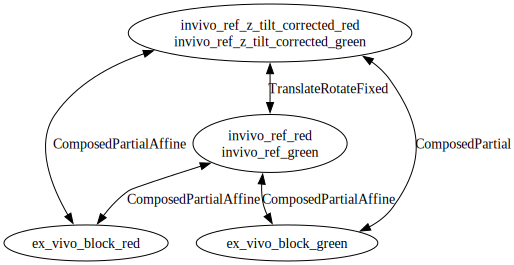

In [35]:
# =============================================================================
# GRAPH STRUCTURE VISUALIZATION
# =============================================================================

print(f"Graph: {g.name}")
print(f"Nodes: {len(g.nodes)}")
print(f"Edges: {sum(len(e) for e in g.edges.values()) // 2}")
print()

# Visualize (uses SVG via patch)
g.visualise()